In [ ]:
!pip install numpy
!pip install matplotlib

In [ ]:
!pip install scipy
!pip install PIP 
!pip install persim
!pip install ripser

In [1]:
import numpy as np

data = np.load("../96x96_tem_downsampled.npy")

print(data.shape)

(17266, 96, 96, 1)


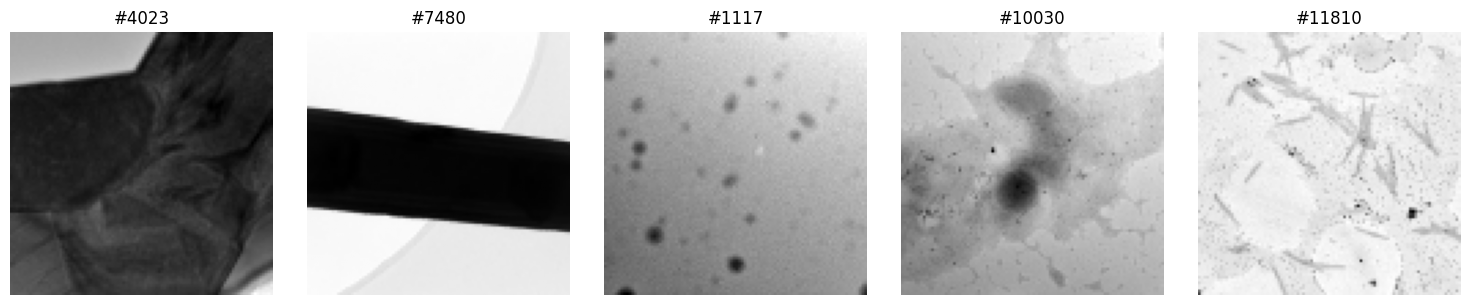

In [2]:
import matplotlib.pyplot as plt

# Pick 5 random indices
idx = np.random.choice(len(data), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, i in zip(axes, idx):
    ax.imshow(data[i].squeeze(), cmap="gray")
    ax.set_title(f"#{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

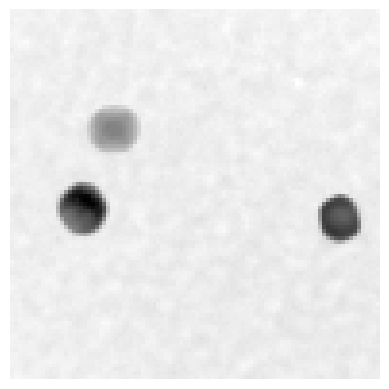

In [3]:
first_image = data[0].squeeze()

plt.imshow(first_image, cmap="gray")
plt.axis("off")
plt.show()

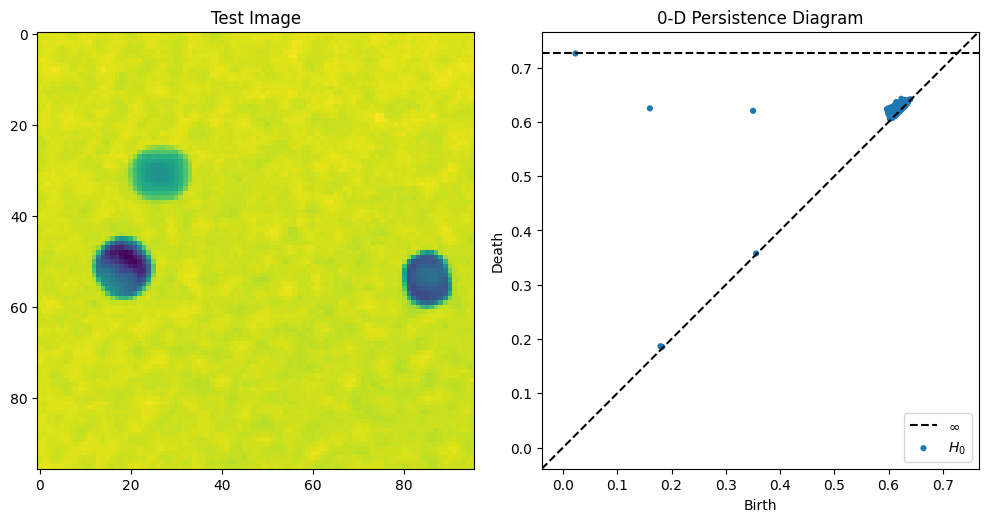

In [4]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img

dgm = lower_star_img(first_image)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(first_image)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

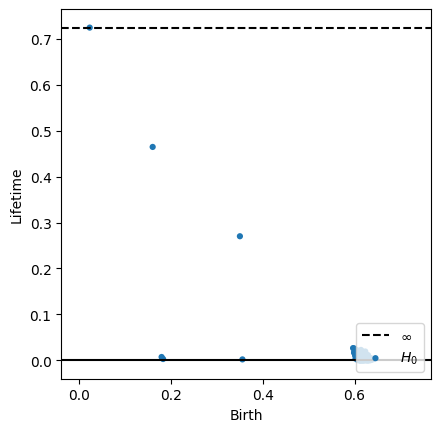

In [8]:
plot_diagrams(dgm, lifetime=True)
plt.show()

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import copy


def segment(threshold, image, dgm):

    pers = dgm[:,1] - dgm[:,0]

    idxs = np.where((pers > threshold) &
                    (dgm[:,1] != np.inf))[0]

    h, w =image.shape

    segmentedpixels = np.zeros((h, w))
    enhanced_contours = []

    for i in idxs:

        birth = dgm[i, 0]

        detected_mask = (image <= birth).astype(np.uint8)

        detected_mask *= 255


        kernel = np.ones((3,3), np.uint8)
        dilated_mask = cv2.dilate(detected_mask, kernel, iterations=2)

        # remove overlap
        non_overlapping_mask = copy.deepcopy(dilated_mask)
        non_overlapping_mask[segmentedpixels > 0] = 0

        segmentedpixels[non_overlapping_mask > 0] = 255

        # contour extraction
        contours, _ = cv2.findContours(
            non_overlapping_mask.astype(np.uint8),
            cv2.RETR_LIST,
            cv2.CHAIN_APPROX_NONE
        )

        for c in contours:
            for pt in c:
                enhanced_contours.append(pt[0].tolist())
    
    slice_contour_img = np.zeros((h, w))

    if len(enhanced_contours) > 0:
        enhanced_contours = np.array(enhanced_contours)

        ys = enhanced_contours[:,1]
        xs = enhanced_contours[:,0]

        slice_contour_img[ys, xs] = 255

    slice_contour_img[0,:] = 255
    slice_contour_img[:,0] = 255
    slice_contour_img[h-1,:] = 255
    slice_contour_img[:,w-1] = 255

    slice_contour_img = slice_contour_img.astype(np.uint8)
    return slice_contour_img

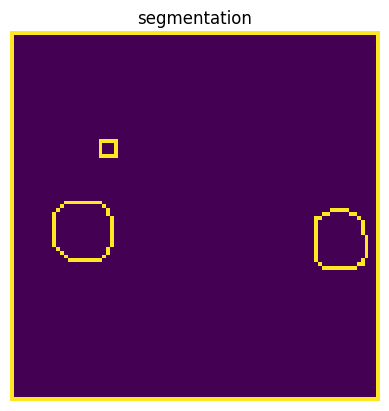

In [ ]:

seg = segment(0.1, first_image, dgm)
plt.imshow(seg)
plt.title("segmentation")
plt.axis("off")
plt.show()

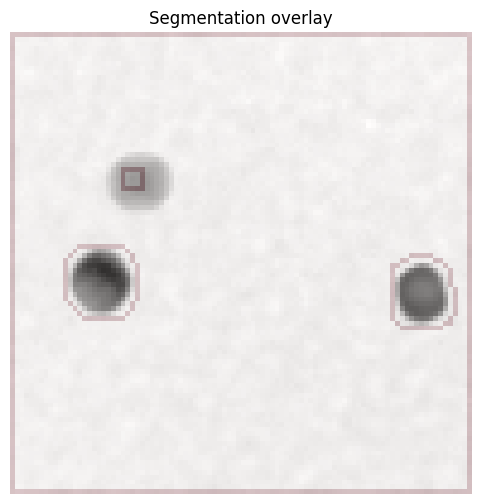

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(first_image, cmap='gray')  
plt.figure(figsize=(6,6))

plt.imshow(first_image, cmap='gray')  

plt.imshow(slice_contour_img, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()
plt.imshow(slice_contour_img, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()

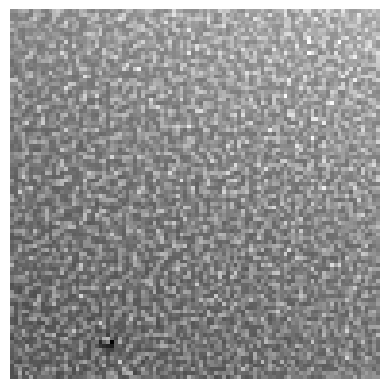

In [14]:
image = data[9358].squeeze()

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

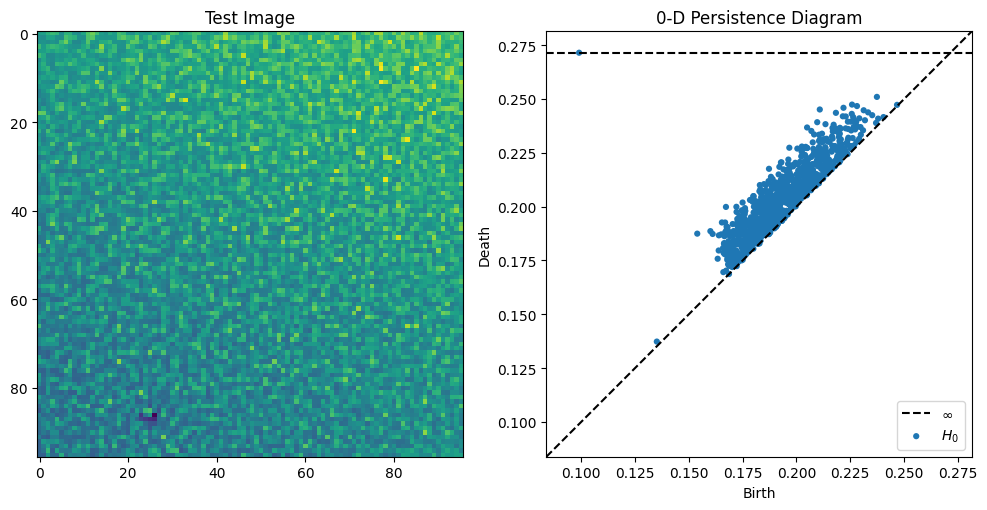

In [16]:
dgm = lower_star_img(image)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

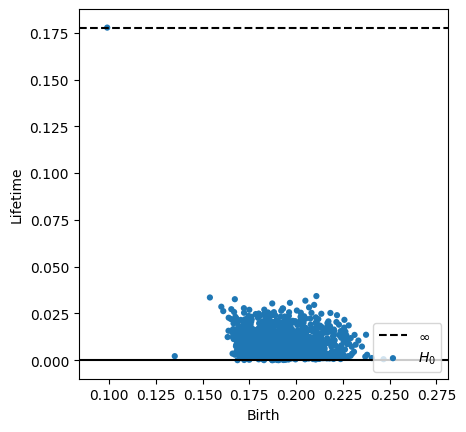

In [17]:
plot_diagrams(dgm, lifetime=True)
plt.show()

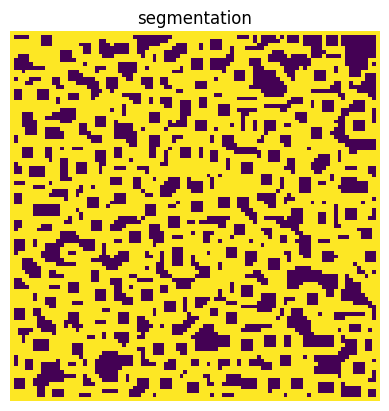

In [18]:
seg = segment(0.02, image, dgm)
plt.imshow(seg)
plt.title("segmentation")
plt.axis("off")
plt.show()

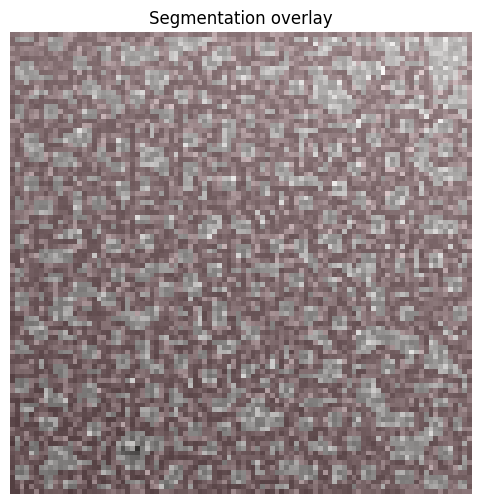

In [19]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')  

plt.imshow(seg, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()


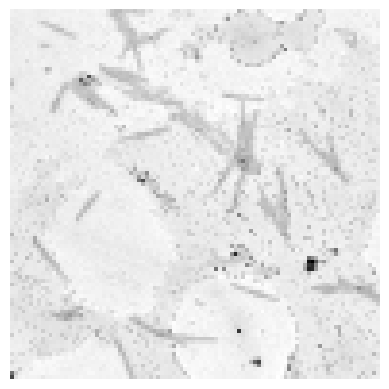

In [36]:
test_image_3 = data[11810].squeeze()

plt.imshow(test_image_3, cmap="gray")
plt.axis("off")
plt.show()

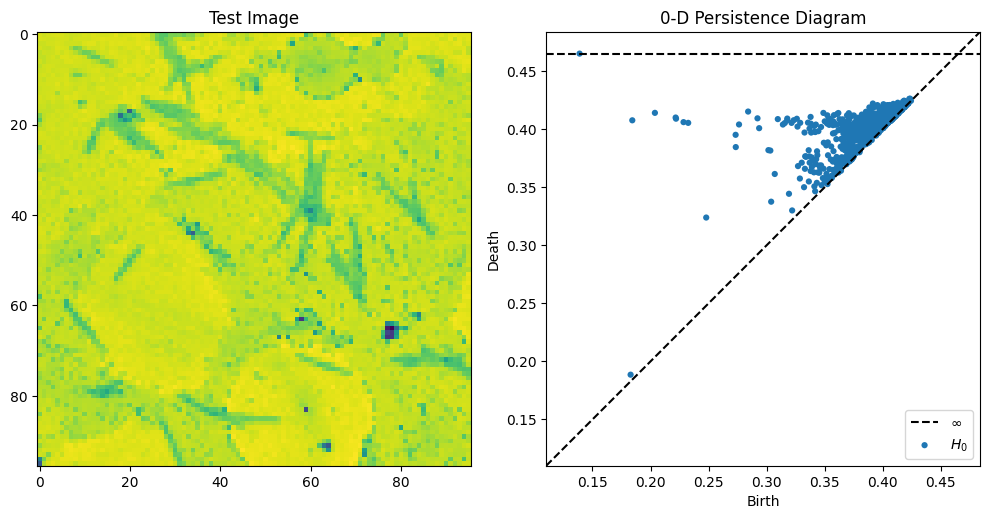

In [59]:
dgm_3 = lower_star_img(test_image_3)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(test_image_3)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm_3)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

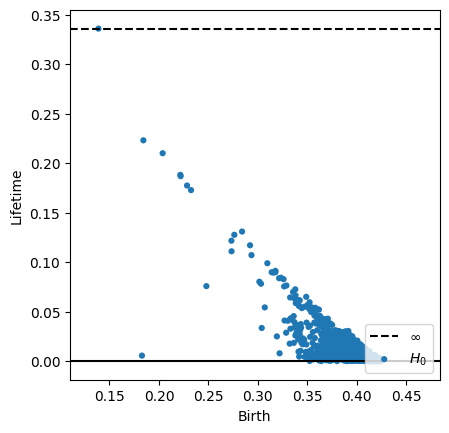

In [38]:
plot_diagrams(dgm_3, lifetime=True)
plt.show()

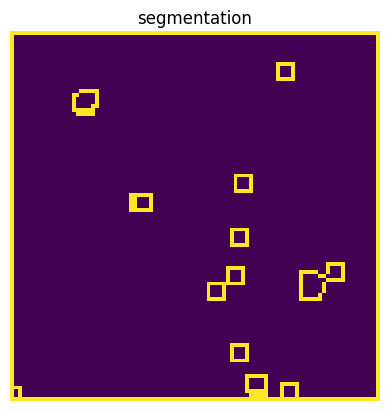

In [42]:
seg_3 = segment(0.1, test_image_3, dgm_3)
plt.imshow(seg_3)
plt.title("segmentation")
plt.axis("off")
plt.show()

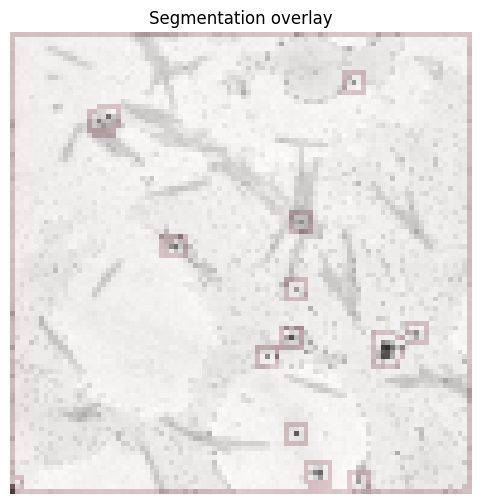

In [43]:
plt.figure(figsize=(6,6))

plt.imshow(test_image_3, cmap='gray')  

plt.imshow(seg_3, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()

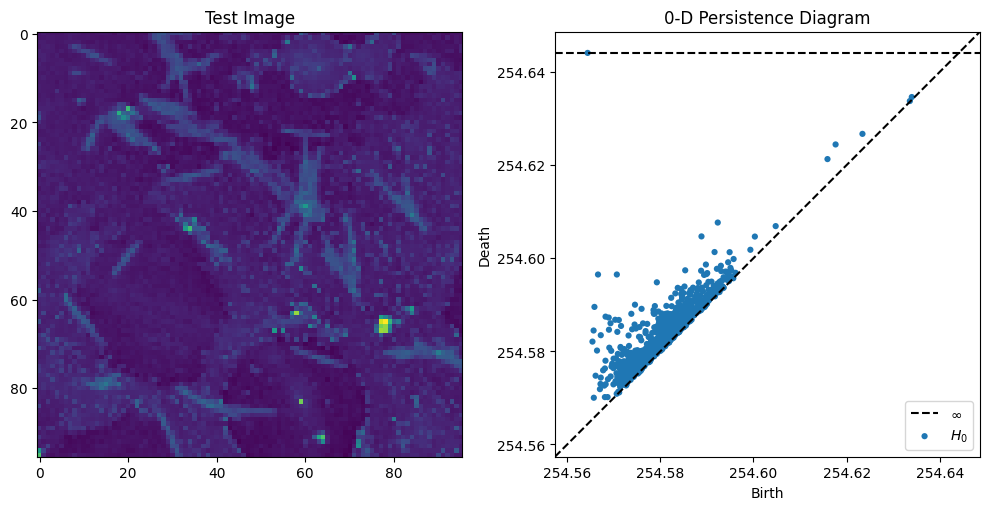

In [89]:
inv_image = 255 - test_image_3
dgm_3_inverse = lower_star_img(inv_image)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(inv_image)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm_3_inverse)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

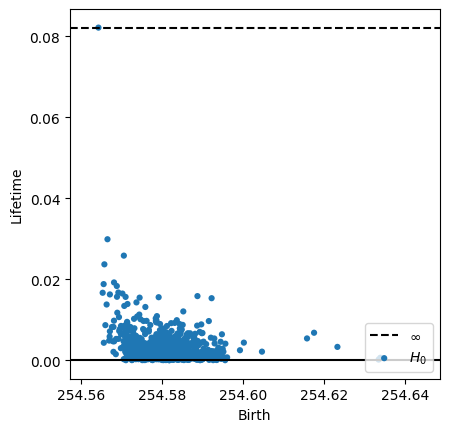

In [90]:
plot_diagrams(dgm_3_inverse, lifetime=True)
plt.show()

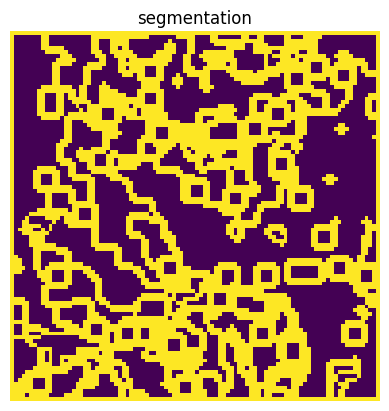

In [104]:
seg_3_inverse = segment(0.015, inv_image, dgm_3_inverse)
plt.imshow(seg_3_inverse)
plt.title("segmentation")
plt.axis("off")
plt.show()

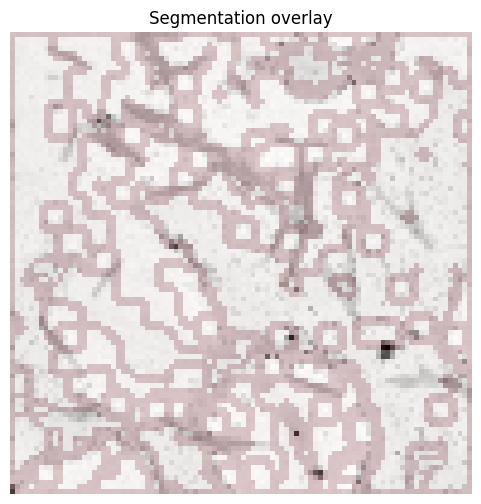

In [106]:
plt.figure(figsize=(6,6))

plt.imshow(test_image_3, cmap='gray')  

plt.imshow(seg_3_inverse, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()